# Liu-Style Longitudinal Figures

Per-patient figures emulating the structure of Liu et al. (2025) Figure 5,
adapted to show all four categories (face, house, object, word) using
category-specific searchmask ROIs.

**For each OTC patient (5 total), three figures:**
- A. RDM heatmaps — one per session
- B. MDS plots — one per session
- C. Pairwise dissimilarity trajectories across sessions (with control band)

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1: Setup + Load Data
# ═══════════════════════════════════════════════════════════════════════════════

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import ttest_rel

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

BASE     = Path(processed_dir)
LIU_DIR  = BASE / 'group_results' / 'liu_distinctiveness'
GEO_DIR  = BASE / 'group_results' / 'geometry'
FIG_DIR  = BASE / 'group_results' / 'figures' / 'liu_style'
FIG_DIR.mkdir(parents=True, exist_ok=True)

COPE_SET   = 'differential'
EXCLUDE    = ['sub-017']
CATEGORIES = ['face', 'house', 'object', 'word']
ALL_PAIRS  = ['face-house', 'face-object', 'face-word',
              'house-object', 'house-word', 'object-word']

CAT_COLORS = {'face': '#cc0066', 'word': '#ff8800', 'house': '#009900', 'object': '#0077cc'}
PAIR_COLORS = {
    'face-house':  '#668844', 'face-object': '#6644aa', 'face-word':   '#cc4400',
    'house-object':'#008888', 'house-word':  '#88aa00', 'object-word': '#cc6600',
}

plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

# ── Load pairwise correlations ────────────────────────────────────────────
pair_file = LIU_DIR / f'pairwise_correlations_{COPE_SET}.csv'
df_pw = pd.read_csv(pair_file)
df_pw = df_pw[df_pw['category'].isin(CATEGORIES)]
df_pw = df_pw[~df_pw['subject_id'].isin(EXCLUDE)]
if 'subject' in df_pw.columns:
    df_pw = df_pw[~df_pw['subject'].str.contains('017')]
df_pw['session'] = pd.to_numeric(df_pw['session'], errors='coerce').astype(int)

# ── Identify OTC longitudinal patients ────────────────────────────────────
otc_pw = df_pw[df_pw['group'] == 'OTC'].copy()
ctrl_pw = df_pw[df_pw['status'] == 'control'].copy()

# OTC patients with 2+ sessions (intact hemi only)
otc_intact = otc_pw[otc_pw['hemi_label'] == 'intact']
ses_per_sub = otc_intact.groupby('subject_id')['session'].nunique()
otc_long_subs = sorted(ses_per_sub[ses_per_sub >= 2].index.tolist())

print(f'Pairwise correlations: {df_pw["subject_id"].nunique()} subjects')
print(f'OTC longitudinal patients: {len(otc_long_subs)}')
for sub in otc_long_subs:
    sd = otc_intact[otc_intact['subject_id'] == sub]
    sessions = sorted(sd['session'].unique())
    surgery = sd['surgery_side'].iloc[0] if 'surgery_side' in sd.columns else '?'
    sub_code = sd['subject'].iloc[0] if 'subject' in sd.columns else sub
    intact = 'LH' if surgery == 'right' else 'RH'
    print(f'  {sub_code} ({sub}): {len(sessions)} sessions {sessions}, intact {intact}')

print(f'\nControls: {ctrl_pw["subject_id"].nunique()} subjects')

Pairwise correlations: 46 subjects
OTC longitudinal patients: 5
  OTC004 (sub-004): 5 sessions [1, 2, 3, 5, 6], intact LH
  OTC008 (sub-008): 2 sessions [1, 2], intact LH
  OTC010 (sub-010): 2 sessions [2, 3], intact RH
  OTC021 (sub-021): 2 sessions [2, 3], intact RH
  OTC079 (sub-079): 2 sessions [1, 2], intact RH

Controls: 22 subjects


In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2: Helper Functions
# ═══════════════════════════════════════════════════════════════════════════════

def build_rdm(df_session_cat):
    """Build a 4x4 RDM from pairwise Fisher r values.
    Input: dataframe filtered to one subject × one session × one hemi,
           with 'pair' and 'fisher_r' columns, category in CATEGORIES.
    Returns: 4x4 numpy array (symmetric, diagonal=0).
    """
    n = len(CATEGORIES)
    rdm = np.full((n, n), np.nan)
    np.fill_diagonal(rdm, 0.0)
    
    for _, row in df_session_cat.iterrows():
        pair = row['pair']
        cats = pair.split('-')
        if cats[0] in CATEGORIES and cats[1] in CATEGORIES:
            i = CATEGORIES.index(cats[0])
            j = CATEGORIES.index(cats[1])
            rdm[i, j] = row['fisher_r']
            rdm[j, i] = row['fisher_r']
    return rdm


def mds_2d(rdm):
    """Classical MDS from a similarity matrix (higher = more similar).
    Convert to dissimilarity first, then MDS.
    """
    # Fisher r: higher = more similar. Convert to distance.
    D = 1 - rdm  # now higher = more different
    np.fill_diagonal(D, 0)
    n = D.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * H @ (D ** 2) @ H
    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    coords = eigvecs[:, :2] * np.sqrt(np.maximum(eigvals[:2], 0))
    return coords


def procrustes_align(ref, target):
    """Align target MDS coordinates to reference using Procrustes."""
    from scipy.linalg import orthogonal_procrustes
    # Center both
    ref_c = ref - ref.mean(axis=0)
    tgt_c = target - target.mean(axis=0)
    R, _ = orthogonal_procrustes(tgt_c, ref_c)
    aligned = tgt_c @ R
    return aligned + ref.mean(axis=0)


def get_control_pairwise_stats(ctrl_df, hemi_label):
    """Compute mean and SD of each pairwise Fisher r across controls for a given hemisphere.
    Uses first session per control.
    Returns dict: pair -> (mean, sd, values_array)
    """
    # First session per control
    first_ses = ctrl_df.groupby('subject_id')['session'].min().reset_index().rename(
        columns={'session': 'fs'})
    ctrl_first = ctrl_df.merge(first_ses, on='subject_id')
    ctrl_first = ctrl_first[ctrl_first['session'] == ctrl_first['fs']]
    ctrl_first = ctrl_first[ctrl_first['hemi_label'] == hemi_label]
    
    stats = {}
    for pair in ALL_PAIRS:
        vals = ctrl_first[ctrl_first['pair'] == pair].groupby('subject_id')['fisher_r'].mean().values
        stats[pair] = (np.nanmean(vals), np.nanstd(vals, ddof=1), vals)
    return stats


# Pre-compute control stats per hemisphere
ctrl_stats_lh = get_control_pairwise_stats(ctrl_pw, 'left')
ctrl_stats_rh = get_control_pairwise_stats(ctrl_pw, 'right')

# Also compute control stats across ALL sessions for trajectory bands
def get_control_trajectory_stats(ctrl_df, hemi_label):
    """Per-session control pairwise stats (for trajectory reference).
    Returns dict: pair -> (overall_mean, overall_sd)
    """
    hemi_df = ctrl_df[ctrl_df['hemi_label'] == hemi_label]
    stats = {}
    for pair in ALL_PAIRS:
        # Pool all sessions (each control contributes multiple sessions)
        vals = hemi_df[hemi_df['pair'] == pair]['fisher_r'].values
        stats[pair] = (np.nanmean(vals), np.nanstd(vals, ddof=1))
    return stats

ctrl_traj_lh = get_control_trajectory_stats(ctrl_pw, 'left')
ctrl_traj_rh = get_control_trajectory_stats(ctrl_pw, 'right')

print('Helper functions loaded.')
print(f'Control pairwise stats: LH {len(ctrl_stats_lh)} pairs, RH {len(ctrl_stats_rh)} pairs')

Helper functions loaded.
Control pairwise stats: LH 6 pairs, RH 6 pairs


/tmp/ipykernel_530051/2254105312.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 0.92])


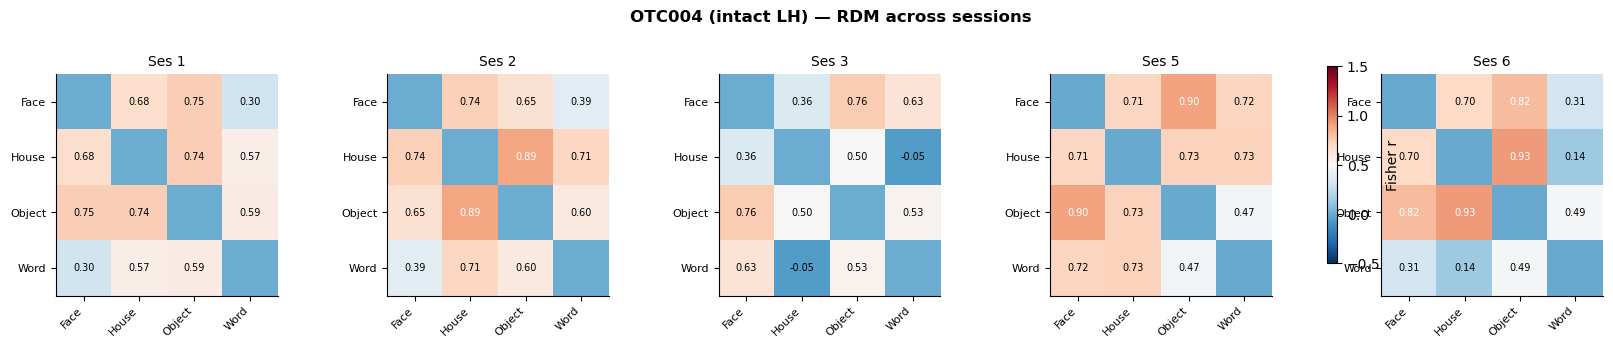

Saved: liu_rdm_sub-004.png


/tmp/ipykernel_530051/2254105312.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 0.92])


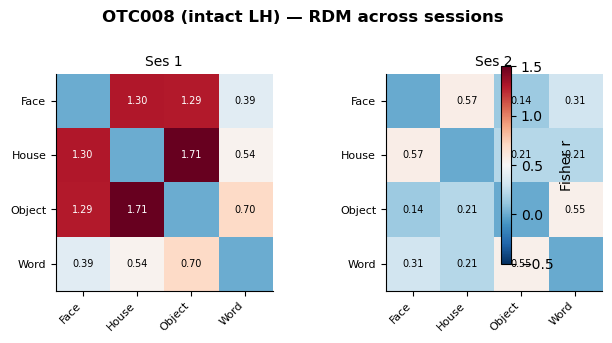

Saved: liu_rdm_sub-008.png


/tmp/ipykernel_530051/2254105312.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 0.92])


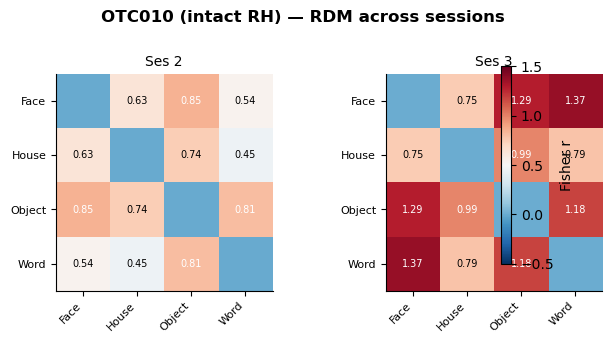

Saved: liu_rdm_sub-010.png


/tmp/ipykernel_530051/2254105312.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 0.92])


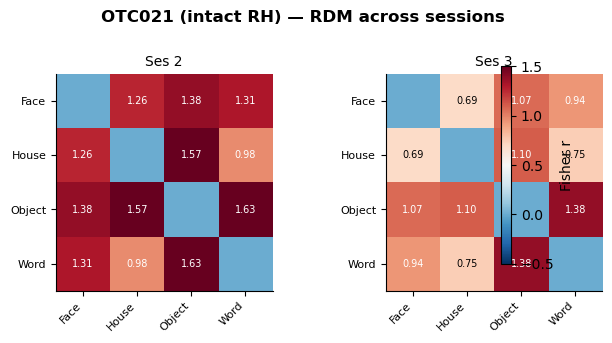

Saved: liu_rdm_sub-021.png


/tmp/ipykernel_530051/2254105312.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 0.92])


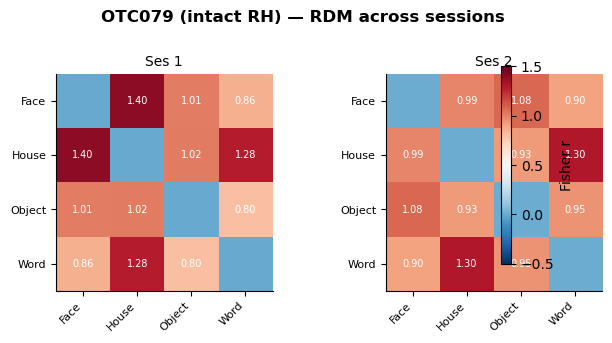

Saved: liu_rdm_sub-079.png


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3: Figure A — RDM Heatmaps per Session per Patient
# ═══════════════════════════════════════════════════════════════════════════════

for sub in otc_long_subs:
    sd = otc_intact[otc_intact['subject_id'] == sub]
    sessions = sorted(sd['session'].unique())
    sub_code = sd['subject'].iloc[0] if 'subject' in sd.columns else sub
    surgery = sd['surgery_side'].iloc[0] if 'surgery_side' in sd.columns else '?'
    intact = 'LH' if surgery == 'right' else 'RH'
    
    n_ses = len(sessions)
    fig, axes = plt.subplots(1, n_ses, figsize=(3.5 * n_ses, 3.2))
    if n_ses == 1:
        axes = [axes]
    
    for si, ses in enumerate(sessions):
        ax = axes[si]
        ses_data = sd[sd['session'] == ses]
        
        # Average across categories (each pair appears once per ROI category)
        ses_avg = ses_data.groupby('pair')['fisher_r'].mean().reset_index()
        rdm = build_rdm(ses_avg)
        
        im = ax.imshow(rdm, cmap='RdBu_r', vmin=-0.5, vmax=1.5, aspect='equal')
        ax.set_xticks(range(4))
        ax.set_xticklabels([c.title() for c in CATEGORIES], fontsize=8, rotation=45, ha='right')
        ax.set_yticks(range(4))
        ax.set_yticklabels([c.title() for c in CATEGORIES], fontsize=8)
        ax.set_title(f'Ses {ses}', fontsize=10)
        
        # Annotate values
        for i in range(4):
            for j in range(4):
                if not np.isnan(rdm[i, j]) and i != j:
                    ax.text(j, i, f'{rdm[i,j]:.2f}', ha='center', va='center',
                            fontsize=7, color='black' if abs(rdm[i,j]) < 0.8 else 'white')
    
    fig.colorbar(im, ax=axes, shrink=0.8, label='Fisher r')
    plt.suptitle(f'{sub_code} (intact {intact}) — RDM across sessions',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 0.95, 0.92])
    fname = f'liu_rdm_{sub}.png'
    plt.savefig(str(FIG_DIR / fname), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

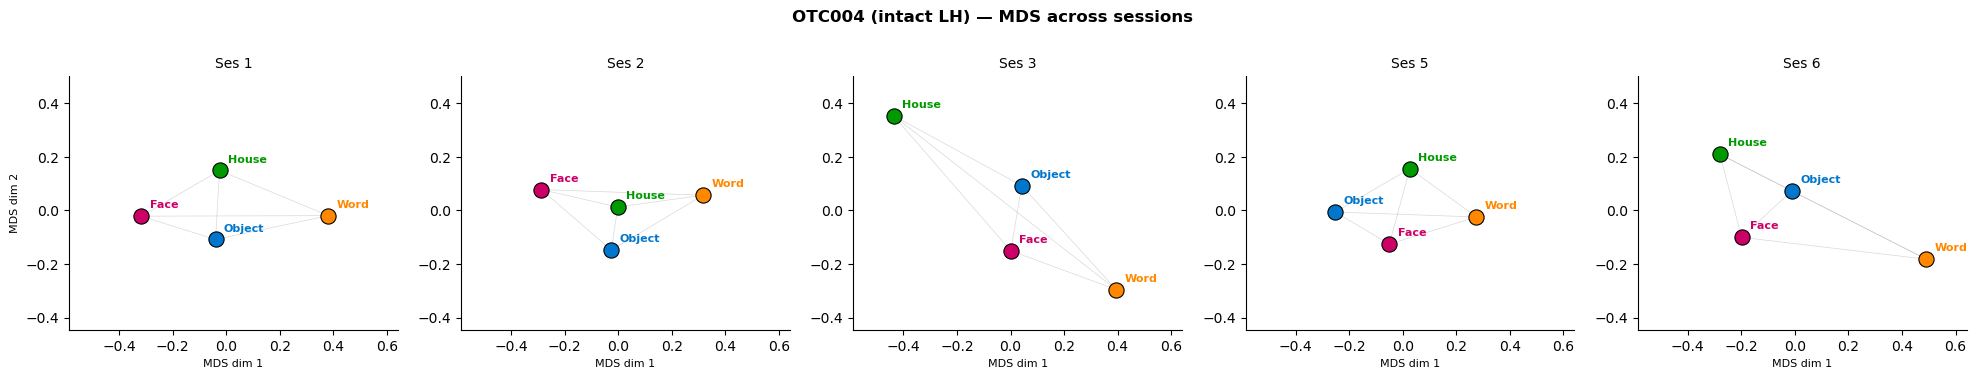

Saved: liu_mds_sub-004.png


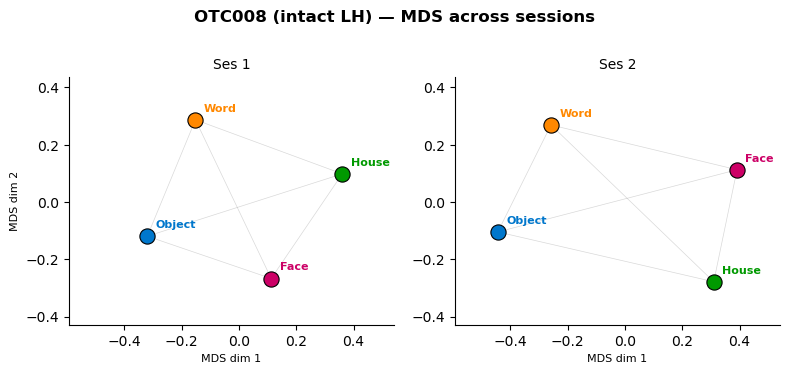

Saved: liu_mds_sub-008.png


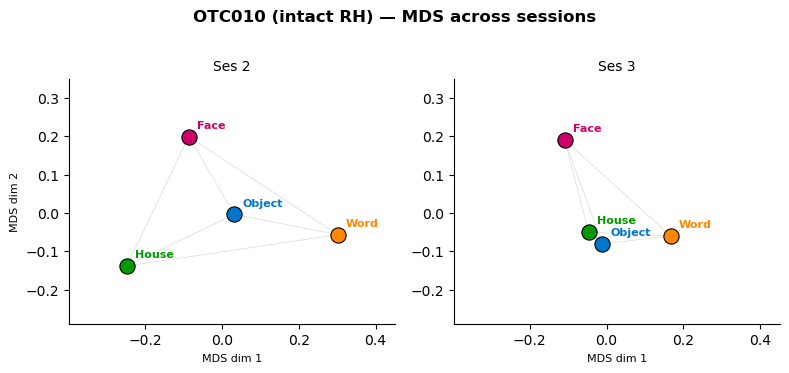

Saved: liu_mds_sub-010.png


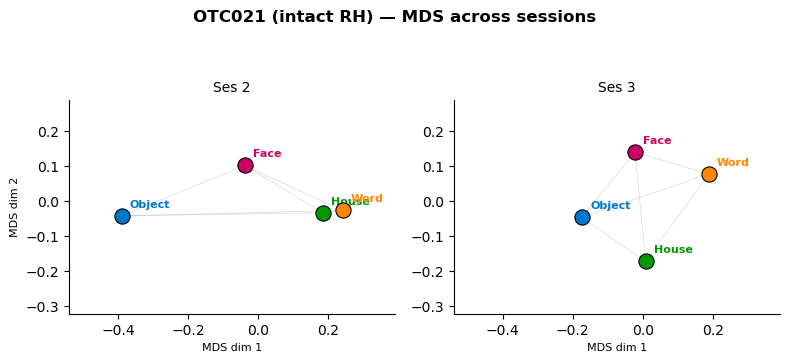

Saved: liu_mds_sub-021.png


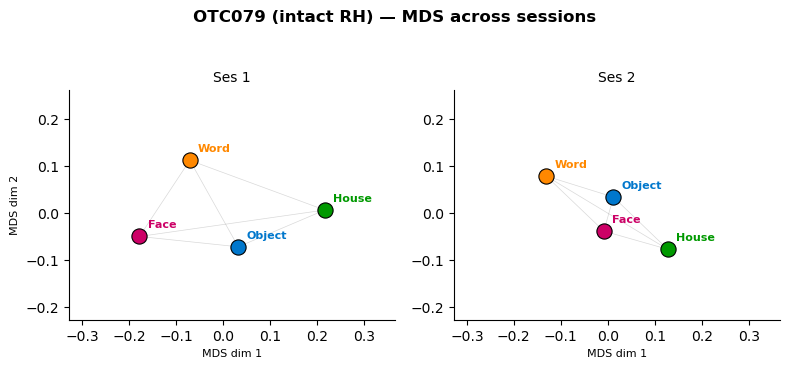

Saved: liu_mds_sub-079.png


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4: Figure B — MDS Plots per Session per Patient
# ═══════════════════════════════════════════════════════════════════════════════

for sub in otc_long_subs:
    sd = otc_intact[otc_intact['subject_id'] == sub]
    sessions = sorted(sd['session'].unique())
    sub_code = sd['subject'].iloc[0] if 'subject' in sd.columns else sub
    surgery = sd['surgery_side'].iloc[0] if 'surgery_side' in sd.columns else '?'
    intact = 'LH' if surgery == 'right' else 'RH'
    
    n_ses = len(sessions)
    fig, axes = plt.subplots(1, n_ses, figsize=(4 * n_ses, 3.5))
    if n_ses == 1:
        axes = [axes]
    
    # Compute MDS for each session, align to first session
    mds_coords = []
    for si, ses in enumerate(sessions):
        ses_data = sd[sd['session'] == ses]
        ses_avg = ses_data.groupby('pair')['fisher_r'].mean().reset_index()
        rdm = build_rdm(ses_avg)
        
        # Check for NaN
        if np.any(np.isnan(rdm)):
            # Fill NaN with row mean (imputation for missing pairs)
            for i in range(4):
                row_mean = np.nanmean(rdm[i, :])
                rdm[i, np.isnan(rdm[i, :])] = row_mean
                rdm[np.isnan(rdm[:, i]), i] = row_mean
        
        coords = mds_2d(rdm)
        mds_coords.append(coords)
    
    # Align all to first session using Procrustes
    ref = mds_coords[0]
    aligned = [ref]
    for i in range(1, len(mds_coords)):
        aligned.append(procrustes_align(ref, mds_coords[i]))
    
    # Find common axis limits
    all_x = np.concatenate([c[:, 0] for c in aligned])
    all_y = np.concatenate([c[:, 1] for c in aligned])
    margin = 0.15
    xlim = (all_x.min() - margin, all_x.max() + margin)
    ylim = (all_y.min() - margin, all_y.max() + margin)
    
    for si, ses in enumerate(sessions):
        ax = axes[si]
        coords = aligned[si]
        
        for ci, cat in enumerate(CATEGORIES):
            ax.scatter(coords[ci, 0], coords[ci, 1],
                       color=CAT_COLORS[cat], s=120, zorder=5,
                       edgecolors='black', linewidth=0.8)
            ax.annotate(cat.title(), (coords[ci, 0], coords[ci, 1]),
                        fontsize=8, fontweight='bold', color=CAT_COLORS[cat],
                        xytext=(6, 6), textcoords='offset points')
        
        # Draw lines between all pairs
        for i in range(4):
            for j in range(i + 1, 4):
                ax.plot([coords[i, 0], coords[j, 0]],
                        [coords[i, 1], coords[j, 1]],
                        color='gray', linewidth=0.5, alpha=0.3, zorder=1)
        
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_title(f'Ses {ses}', fontsize=10)
        ax.set_xlabel('MDS dim 1', fontsize=8)
        if si == 0:
            ax.set_ylabel('MDS dim 2', fontsize=8)
        ax.set_aspect('equal')
    
    plt.suptitle(f'{sub_code} (intact {intact}) — MDS across sessions',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    fname = f'liu_mds_{sub}.png'
    plt.savefig(str(FIG_DIR / fname), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

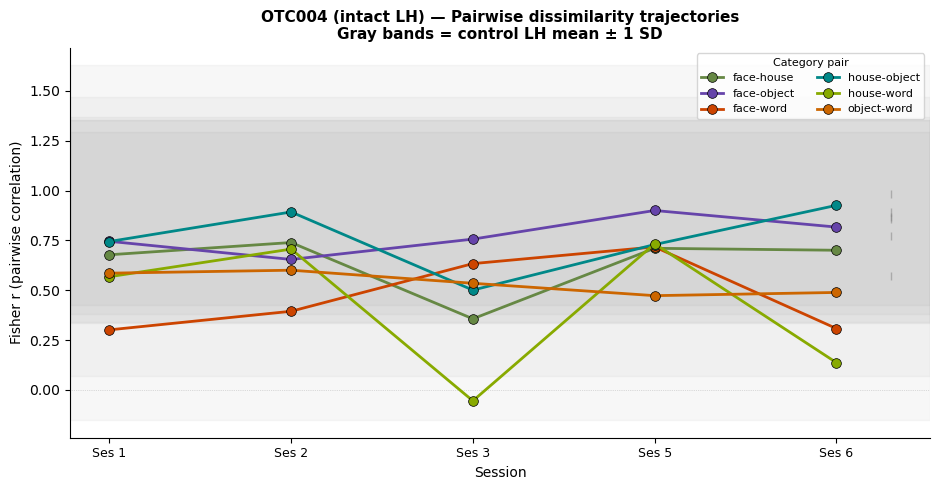

Saved: liu_trajectories_sub-004.png


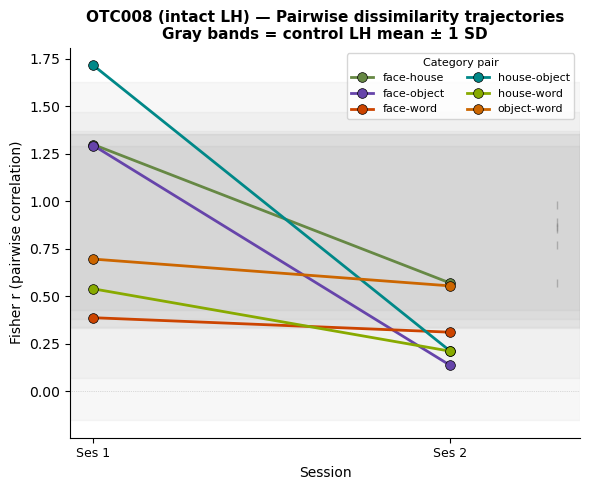

Saved: liu_trajectories_sub-008.png


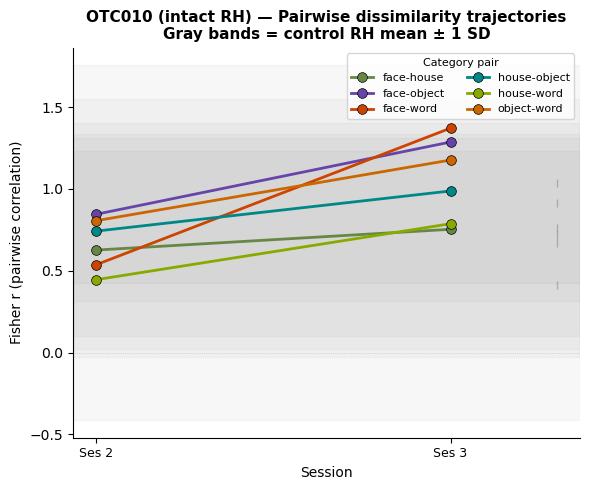

Saved: liu_trajectories_sub-010.png


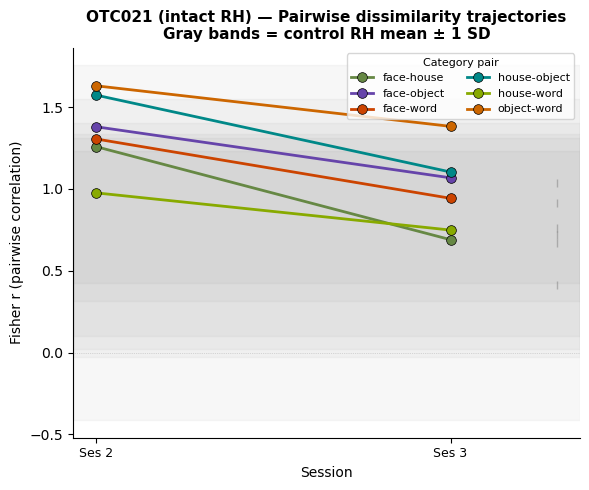

Saved: liu_trajectories_sub-021.png


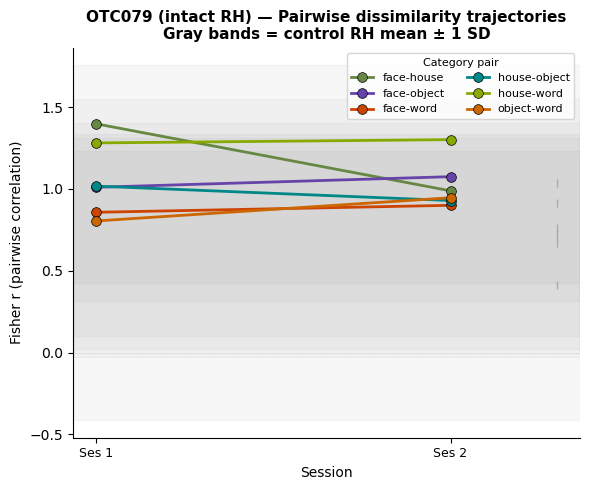

Saved: liu_trajectories_sub-079.png


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5: Figure C — Pairwise Dissimilarity Trajectories per Patient
# ═══════════════════════════════════════════════════════════════════════════════
# All 6 pairwise Fisher r values across sessions.
# Control distribution shown as shaded ±1 SD band.

for sub in otc_long_subs:
    sd = otc_intact[otc_intact['subject_id'] == sub]
    sessions = sorted(sd['session'].unique())
    sub_code = sd['subject'].iloc[0] if 'subject' in sd.columns else sub
    surgery = sd['surgery_side'].iloc[0] if 'surgery_side' in sd.columns else '?'
    intact_hemi = 'left' if surgery == 'right' else 'right'
    intact_label = 'LH' if intact_hemi == 'left' else 'RH'
    
    # Get control stats for matching hemisphere
    ctrl_stats = ctrl_traj_lh if intact_hemi == 'left' else ctrl_traj_rh
    
    fig, ax = plt.subplots(figsize=(max(6, len(sessions) * 1.5 + 2), 5))
    
    # ── Control reference bands ───────────────────────────────────────
    for pair in ALL_PAIRS:
        m, s = ctrl_stats[pair]
        ax.axhspan(m - s, m + s, alpha=0.06, color='gray', zorder=0)
        # Small marker at right edge for control mean
        ax.plot(len(sessions) - 0.7, m, marker='|', color='gray', markersize=6, alpha=0.5)
    
    # ── Patient trajectories ──────────────────────────────────────────
    for pair in ALL_PAIRS:
        pair_vals = []
        for ses in sessions:
            ses_data = sd[(sd['session'] == ses) & (sd['pair'] == pair)]
            if len(ses_data) > 0:
                # Average across ROI categories for this pair
                pair_vals.append(ses_data['fisher_r'].mean())
            else:
                pair_vals.append(np.nan)
        
        color = PAIR_COLORS[pair]
        ax.plot(range(len(sessions)), pair_vals, '-o', color=color,
                linewidth=2, markersize=7, label=pair, zorder=3,
                markeredgecolor='black', markeredgewidth=0.5)
    
    ax.set_xticks(range(len(sessions)))
    ax.set_xticklabels([f'Ses {s}' for s in sessions], fontsize=9)
    ax.set_ylabel('Fisher r (pairwise correlation)', fontsize=10)
    ax.set_xlabel('Session', fontsize=10)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle=':', alpha=0.5)
    
    ax.legend(loc='upper right', fontsize=8, frameon=True, ncol=2,
              title='Category pair', title_fontsize=8)
    
    plt.title(f'{sub_code} (intact {intact_label}) — Pairwise dissimilarity trajectories\n'
              f'Gray bands = control {intact_label} mean ± 1 SD',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    fname = f'liu_trajectories_{sub}.png'
    plt.savefig(str(FIG_DIR / fname), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

/tmp/ipykernel_530051/3287372792.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 0.92])


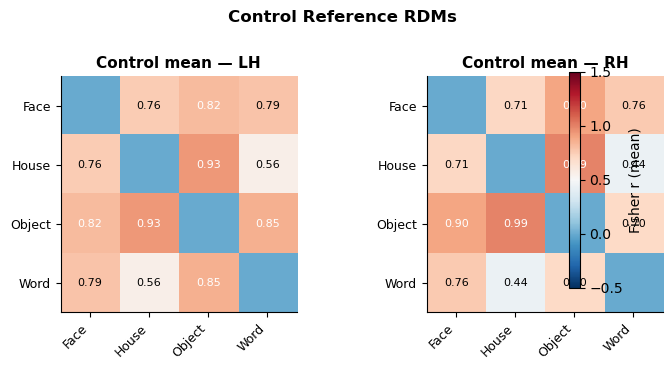

Saved: liu_ctrl_rdm_reference.png


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6: Control Reference RDMs (one per hemisphere)
# ═══════════════════════════════════════════════════════════════════════════════
# Mean control RDM for LH and RH as a visual reference.

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

for hi, (hemi, hemi_label) in enumerate([('left', 'LH'), ('right', 'RH')]):
    ax = axes[hi]
    ctrl_stats = ctrl_stats_lh if hemi == 'left' else ctrl_stats_rh
    
    rdm = np.zeros((4, 4))
    for pair, (m, s, _) in ctrl_stats.items():
        cats = pair.split('-')
        i = CATEGORIES.index(cats[0])
        j = CATEGORIES.index(cats[1])
        rdm[i, j] = m
        rdm[j, i] = m
    
    im = ax.imshow(rdm, cmap='RdBu_r', vmin=-0.5, vmax=1.5, aspect='equal')
    ax.set_xticks(range(4))
    ax.set_xticklabels([c.title() for c in CATEGORIES], fontsize=9, rotation=45, ha='right')
    ax.set_yticks(range(4))
    ax.set_yticklabels([c.title() for c in CATEGORIES], fontsize=9)
    ax.set_title(f'Control mean — {hemi_label}', fontsize=11, fontweight='bold')
    
    for i in range(4):
        for j in range(4):
            if i != j:
                ax.text(j, i, f'{rdm[i,j]:.2f}', ha='center', va='center',
                        fontsize=8, color='black' if abs(rdm[i,j]) < 0.8 else 'white')

fig.colorbar(im, ax=axes, shrink=0.8, label='Fisher r (mean)')
plt.suptitle('Control Reference RDMs', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.92, 0.92])
plt.savefig(str(FIG_DIR / 'liu_ctrl_rdm_reference.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: liu_ctrl_rdm_reference.png')